# CommonLII LKCA layout EDA

This notebook scans every HTML judgment in `data/commonlii/raw/LKCA`, generates
reproducible HTML-layout fingerprints, and explores how the layouts change over
time. It mirrors `data/commonlii/eda.ipynb` (the LKSC EDA) in method and style,
but is a **separate notebook writing to separate output paths** so nothing here
touches Himath's LKSC files, report, or charts.

Categorization and parsing are done entirely by the existing pipeline scripts
(`build_layout_categories.py`, `src/parsers/split_categories.py`) via
subprocess, exactly as the LKSC notebook does — this notebook only loads their
output and charts it. One deliberate difference from the LKSC notebook: it
skips the cell that re-implements the scoring formula in Python as a
cross-check against the generator. That's a duplicate of pipeline logic, and
this notebook's job is analysis, not re-implementation -- the discrete bucket
counts (Part 2 below) already provide an independent, from-the-real-pipeline
check on the continuous scores.


## 1. Imports and configuration

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

sns.set_theme(style="whitegrid", context="notebook")


def find_repo_root():
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "pyproject.toml").exists()
            and (candidate / "data/commonlii/raw/LKCA").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not locate the repository root containing pyproject.toml "
        "and data/commonlii/raw/LKCA."
    )


REPO_ROOT = find_repo_root()
HTML_ROOT = REPO_ROOT / "data/commonlii/raw/LKCA"

# LKCA-only output paths -- never the same file as the LKSC EDA.
JSON_PATH = REPO_ROOT / "data/commonlii/layout-categories-LKCA.json"
CATEGORIES_DIR = REPO_ROOT / "data/commonlii/layout-categories-LKCA"
OUTPUT_DIR = REPO_ROOT / "data/commonlii/layout-eda-LKCA"

GENERATOR_PATH = REPO_ROOT / "scripts/commonlli-scraper/build_layout_categories.py"
SPLIT_PATH = REPO_ROOT / "src/parsers/split_categories.py"

LAYOUTS = [
    "paragraph_nlr",
    "dense_br_nlr",
    "structured_slr",
    "late_slr_font",
]

COLORS = {
    "paragraph_nlr": "#2563EB",
    "dense_br_nlr": "#F59E0B",
    "structured_slr": "#10B981",
    "late_slr_font": "#DC2626",
    "uncertain": "#6B7280",
}

for path in (GENERATOR_PATH, SPLIT_PATH):
    if not path.exists():
        raise FileNotFoundError(f"Required pipeline script not found: {path}")

print(f"HTML archive: {HTML_ROOT}")
print(f"Fingerprint report (LKCA only): {JSON_PATH}")
print(f"Discrete category buckets (LKCA only): {CATEGORIES_DIR}")


HTML archive: C:\Users\ASUS\Desktop\DSEP\Draftly\data\commonlii\raw\LKCA
Fingerprint report (LKCA only): C:\Users\ASUS\Desktop\DSEP\Draftly\data\commonlii\layout-categories-LKCA.json
Discrete category buckets (LKCA only): C:\Users\ASUS\Desktop\DSEP\Draftly\data\commonlii\layout-categories-LKCA


## 2. Generate the continuous layout scores

Runs `build_layout_categories.py` -- the exact same generator the LKSC EDA
uses -- pointed at `data/commonlii/raw/LKCA` and writing to a LKCA-only report
file. Rebuilt from every HTML file on each run.

In [2]:
completed = subprocess.run(
    [
        sys.executable,
        str(GENERATOR_PATH),
        "--input",
        str(HTML_ROOT),
        "--output",
        str(JSON_PATH),
    ],
    check=True,
    capture_output=True,
    text=True,
)
print(completed.stdout.strip())

report = json.loads(JSON_PATH.read_text(encoding="utf-8"))

if report.get("errors"):
    raise RuntimeError(f"Fingerprint failures: {report['errors'][:5]}")
if not isinstance(report.get("files"), list) or not report["files"]:
    raise ValueError("The generated report does not contain fingerprint records.")
if report["html_files_found"] != report["html_files_fingerprinted"]:
    raise ValueError(
        "Not every HTML file was fingerprinted: "
        f"{report['html_files_fingerprinted']} / {report['html_files_found']}"
    )

df = pd.json_normalize(report["files"], sep=".")
required_columns = {"file", "year", "report_series", "category"}
missing_required = sorted(required_columns - set(df.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df["year"] = pd.to_numeric(df["year"], errors="raise").astype(int)
df = df.sort_values(["year", "file"]).reset_index(drop=True)

# The generator's own layout_scores.<name> columns become bare LAYOUTS columns
# for charting -- values taken directly from the pipeline, not recomputed.
for layout in LAYOUTS:
    df[layout] = df[f"layout_scores.{layout}"]

print(f"HTML files analysed: {len(df):,}")
print(f"PDF files skipped: {report['pdf_files_skipped']:,}")
print(f"Year coverage: {df['year'].min()} to {df['year'].max()}")
display(df[["file", "year", "report_series", "category", "confidence"] + LAYOUTS].head())


Fingerprinted 7439 HTML files; skipped 0 PDFs; wrote C:\Users\ASUS\Desktop\DSEP\Draftly\data\commonlii\layout-categories-LKCA.json


HTML files analysed: 7,439
PDF files skipped: 0
Year coverage: 1878 to 2010


,file,year,report_series,category,confidence,paragraph_nlr,dense_br_nlr,structured_slr,late_slr_font
0,1878/1.html,1878,NLR,paragraph_nlr,0.903453,0.903453,0.016547,0.079121,0.000879
1,1878/2.html,1878,NLR,dense_br_nlr,0.919842,0.000158,0.919842,0.078006,0.001994
2,1878/3.html,1878,NLR,paragraph_nlr,0.903453,0.903453,0.016547,0.076669,0.003331
3,1878/4.html,1878,NLR,dense_br_nlr,0.919979,0.000021,0.919979,0.070464,0.009536
4,1878/5.html,1878,NLR,dense_br_nlr,0.919998,0.000002,0.919998,0.070464,0.009536


## 3. Discrete bucket breakdown (per family + "uncertain")

Runs `split_categories.py` -- the same script `src/parsers/parse_archive.py`
consumes -- against the LKCA report, writing to a LKCA-only bucket directory.
This is the real pipeline's own bucket assignment, not a notebook-side
re-derivation: `uncertain` = top score < 0.75 or top-two margin < 0.5,
computed by the script itself.

paragraph_nlr: 1211
dense_br_nlr: 4516
structured_slr: 1436
late_slr_font: 246
uncertain: 30
total: 7439 -> C:\Users\ASUS\Desktop\DSEP\Draftly\data\commonlii\layout-categories-LKCA


,bucket,files,share
0,paragraph_nlr,1211,0.1628
1,dense_br_nlr,4516,0.6071
2,structured_slr,1436,0.1930
3,late_slr_font,246,0.0331
4,uncertain,30,0.0040


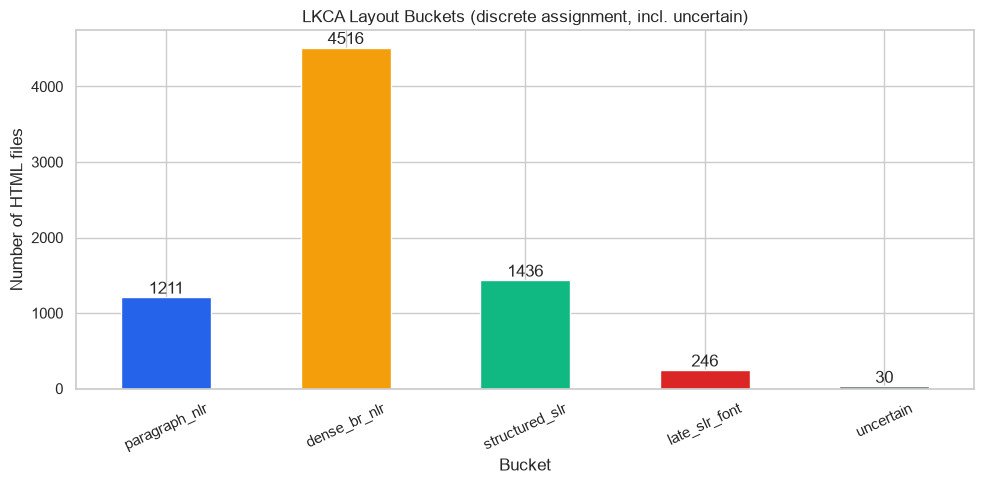


uncertain: 30 of 7439 files (0.4%)


In [3]:
completed = subprocess.run(
    [
        sys.executable,
        str(SPLIT_PATH),
        "--report",
        str(JSON_PATH),
        "--output-dir",
        str(CATEGORIES_DIR),
    ],
    check=True,
    capture_output=True,
    text=True,
)
print(completed.stdout.strip())

bucket_order = LAYOUTS + ["uncertain"]
bucket_counts = {}
for bucket in bucket_order:
    payload = json.loads((CATEGORIES_DIR / f"{bucket}.json").read_text(encoding="utf-8"))
    bucket_counts[bucket] = payload["file_count"]

bucket_df = (
    pd.Series(bucket_counts, name="files")
    .reindex(bucket_order)
    .rename_axis("bucket")
    .reset_index()
)
bucket_df["share"] = (bucket_df["files"] / bucket_df["files"].sum()).round(4)
display(bucket_df)

ax = bucket_df.set_index("bucket")["files"].plot(
    kind="bar",
    figsize=(10, 5),
    color=[COLORS[b] for b in bucket_order],
)
ax.set_title("LKCA Layout Buckets (discrete assignment, incl. uncertain)")
ax.set_xlabel("Bucket")
ax.set_ylabel("Number of HTML files")
ax.tick_params(axis="x", rotation=25)
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

UNCERTAIN_COUNT = bucket_counts["uncertain"]
UNCERTAIN_SHARE = UNCERTAIN_COUNT / bucket_df["files"].sum()
print(f"\nuncertain: {UNCERTAIN_COUNT} of {bucket_df['files'].sum()} files ({UNCERTAIN_SHARE:.1%})")


## 4. If "uncertain" is large: inspect examples for a possible 5th format

Only runs its output meaningfully if the uncertain share above is large enough
to be worth a look. Pulls a spread of the lowest-confidence uncertain files
(by year) and shows a short raw-HTML excerpt from each -- the point is to
eyeball whether they're genuinely ambiguous cases of the 4 known families, or
something structurally different (a candidate 5th layout).

In [4]:
UNCERTAIN_LARGE_THRESHOLD = 0.05  # >5% of the archive is worth a manual look

uncertain_payload = json.loads((CATEGORIES_DIR / "uncertain.json").read_text(encoding="utf-8"))
uncertain_records = uncertain_payload["files"]

if UNCERTAIN_SHARE < UNCERTAIN_LARGE_THRESHOLD:
    print(
        f"uncertain is {UNCERTAIN_SHARE:.1%} of the archive, under the "
        f"{UNCERTAIN_LARGE_THRESHOLD:.0%} threshold -- not large enough to warrant "
        "a manual 5th-format check. Skipping example inspection."
    )
else:
    uncertain_df = pd.json_normalize(uncertain_records, sep=".").sort_values("year")
    # Spread examples across the year range rather than clustering in one era.
    sample_idx = np.linspace(0, len(uncertain_df) - 1, num=min(6, len(uncertain_df))).astype(int)
    sample = uncertain_df.iloc[sample_idx]

    print(f"uncertain is {UNCERTAIN_SHARE:.1%} of the archive -- showing {len(sample)} examples\n")

    for _, row in sample.iterrows():
        path = HTML_ROOT / row["file"]
        raw = path.read_text(encoding="utf-8", errors="replace")
        # Strip tags crudely for a readable excerpt; this is just for eyeballing.
        import re
        text_only = re.sub(r"<[^>]+>", " ", raw)
        text_only = re.sub(r"\s+", " ", text_only).strip()
        print(f"--- {row['file']}  (year {row['year']}, series {row.get('report_series')}, "
              f"top layout_scores: {row.get('category')}={row.get('confidence'):.2f}) ---")
        print(text_only[:400])
        print()


uncertain is 0.4% of the archive, under the 5% threshold -- not large enough to warrant a manual 5th-format check. Skipping example inspection.


## 5. Four layout curves over time

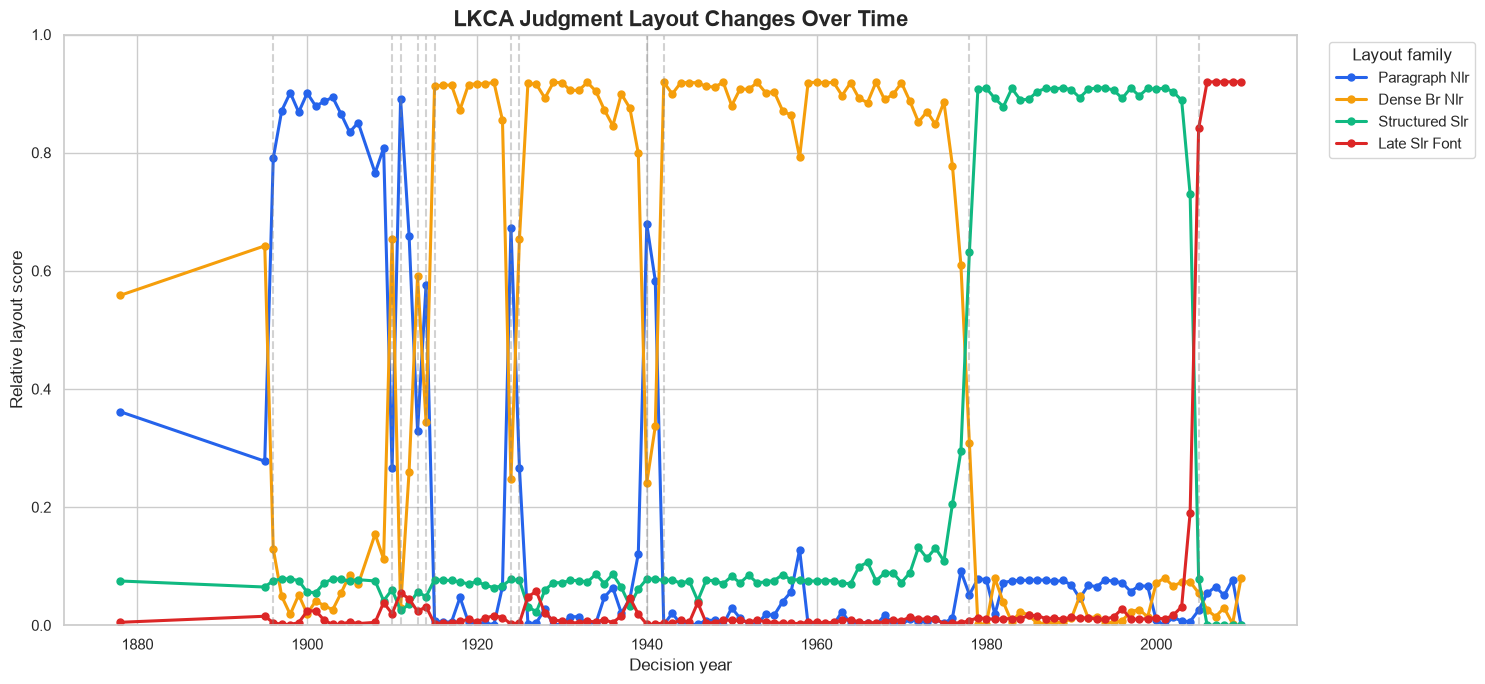

In [5]:
yearly_scores = df.groupby("year")[LAYOUTS].mean().sort_index()
dominant_layout = yearly_scores.idxmax(axis=1)
change_years = dominant_layout[dominant_layout.ne(dominant_layout.shift())].index.tolist()

fig, ax = plt.subplots(figsize=(15, 7))

for layout in LAYOUTS:
    ax.plot(
        yearly_scores.index,
        yearly_scores[layout],
        marker="o",
        linewidth=2.2,
        markersize=5,
        label=layout.replace("_", " ").title(),
        color=COLORS[layout],
    )

for year in change_years[1:]:
    ax.axvline(year, color="grey", linestyle="--", alpha=0.35)

ax.set_title("LKCA Judgment Layout Changes Over Time", fontsize=16, fontweight="bold")
ax.set_xlabel("Decision year")
ax.set_ylabel("Relative layout score")
ax.set_ylim(0, 1)
ax.legend(title="Layout family", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


## 6. Layout heatmap by year

Scores are averaged by year before plotting, so the full 1878-2010 span
remains readable even where a year contains many judgments.

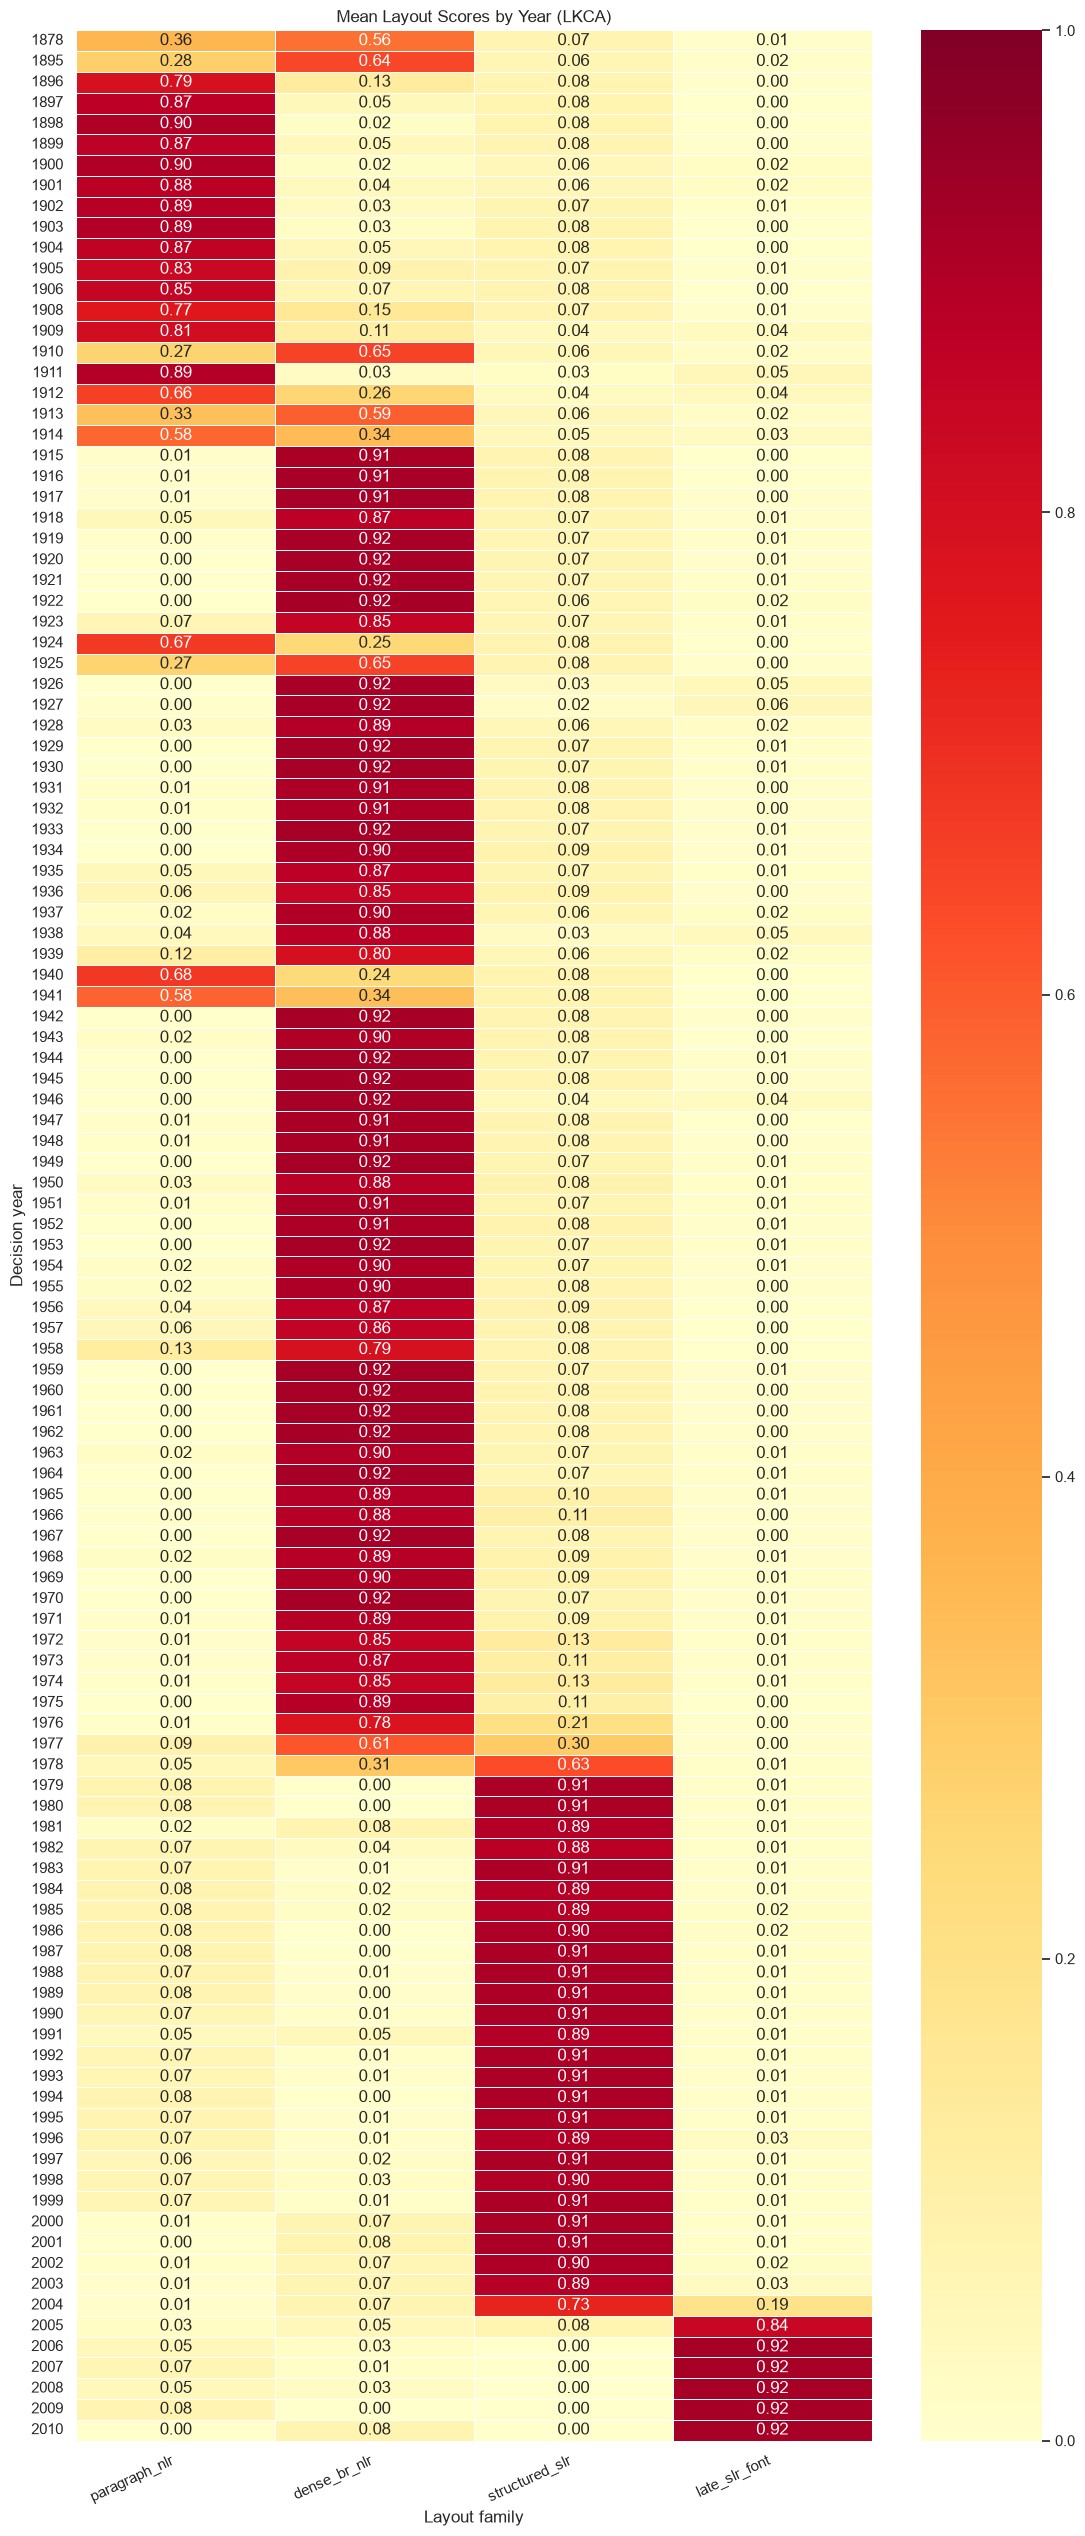

In [6]:
plt.figure(figsize=(11, min(30, max(8, len(yearly_scores) * 0.22))))

sns.heatmap(
    yearly_scores,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
)

plt.title("Mean Layout Scores by Year (LKCA)")
plt.xlabel("Layout family")
plt.ylabel("Decision year")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()


## 7. Candidate layout transitions

In [7]:
timeline = yearly_scores.copy()
timeline["dominant_layout"] = timeline.idxmax(axis=1)
timeline["dominant_score"] = yearly_scores.max(axis=1)
timeline["layout_changed"] = timeline["dominant_layout"].ne(
    timeline["dominant_layout"].shift()
)

transitions = timeline.loc[
    timeline["layout_changed"],
    ["dominant_layout", "dominant_score"],
]

display(transitions)


,dominant_layout,dominant_score
year,,
1878,dense_br_nlr,0.558583
1896,paragraph_nlr,0.790578
1910,dense_br_nlr,0.654180
1911,paragraph_nlr,0.890687
1913,dense_br_nlr,0.591027
1914,paragraph_nlr,0.575996
1915,dense_br_nlr,0.912384
1924,paragraph_nlr,0.673061
1925,dense_br_nlr,0.654186


## 8. Layout composition by decade

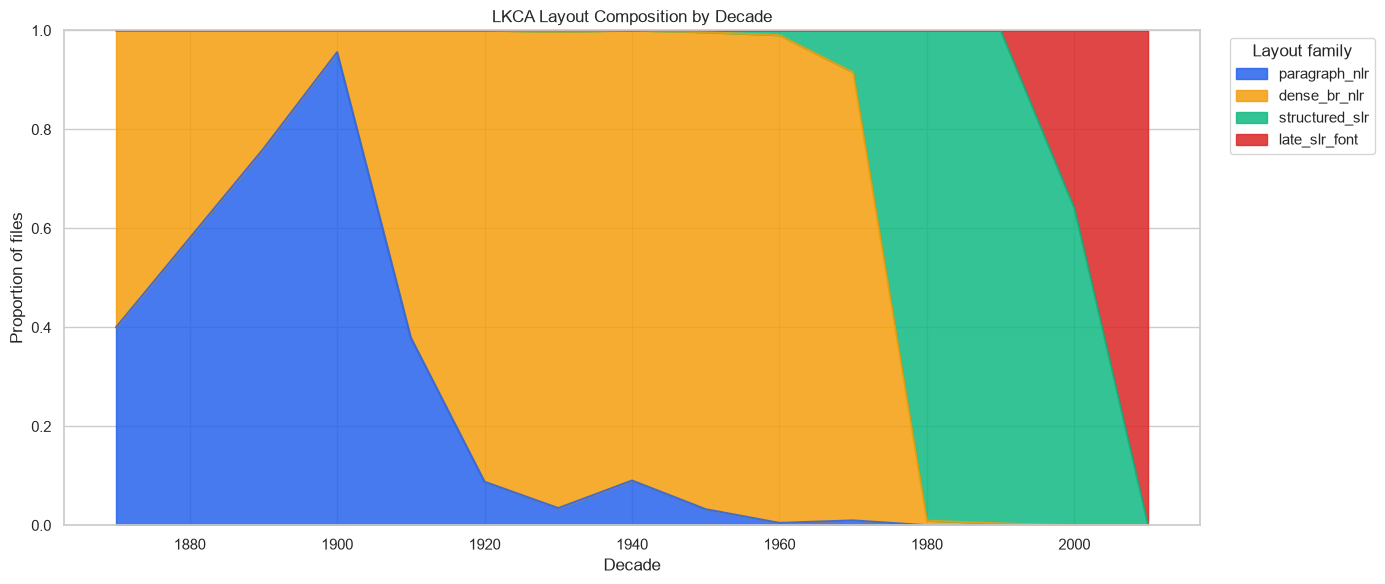

In [8]:
df["decade"] = (df["year"] // 10) * 10

decade_distribution = pd.crosstab(
    df["decade"],
    df["category"],
    normalize="index",
).reindex(columns=LAYOUTS, fill_value=0)

ax = decade_distribution.plot(
    kind="area",
    stacked=True,
    figsize=(14, 6),
    color=[COLORS[layout] for layout in LAYOUTS],
    alpha=0.85,
)

ax.set_title("LKCA Layout Composition by Decade")
ax.set_xlabel("Decade")
ax.set_ylabel("Proportion of files")
ax.set_ylim(0, 1)
ax.legend(title="Layout family", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


## 9. Suspicious or low-confidence files (continuous-score view)

Complements the discrete `uncertain` bucket in Part 3: flags files with a top
score below 0.75 or a top-two margin below 0.5 -- the same thresholds
`split_categories.py` uses, applied here directly to the continuous scores for
a sortable table.

In [9]:
df["top_score"] = df[LAYOUTS].max(axis=1)
sorted_scores = np.sort(df[LAYOUTS].to_numpy(), axis=1)
df["score_margin"] = sorted_scores[:, -1] - sorted_scores[:, -2]

uncertain = df[(df["top_score"] < 0.75) | (df["score_margin"] < 0.5)]

print(f"Uncertain files: {len(uncertain)} of {len(df)}")
display(
    uncertain[
        ["file", "year", "category", "top_score", "score_margin"] + LAYOUTS
    ].sort_values("score_margin")
)


Uncertain files: 30 of 7439


,file,year,category,top_score,score_margin,paragraph_nlr,dense_br_nlr,structured_slr,late_slr_font
5766,1977/3.html,1977,paragraph_nlr,0.480894,0.041788,0.480894,0.439106,0.078280,0.001720
4033,1950/27.html,1950,dense_br_nlr,0.493328,0.066656,0.426672,0.493328,0.079009,0.000991
5984,1985/23.html,1985,structured_slr,0.532903,0.145806,0.077886,0.002114,0.532903,0.387097
3457,1943/23.html,1943,paragraph_nlr,0.542727,0.165454,0.542727,0.377273,0.079121,0.000879
5751,1977/10.html,1977,paragraph_nlr,0.553057,0.186114,0.553057,0.366943,0.078127,0.001873
7270,2005/71.html,2005,structured_slr,0.578998,0.237996,0.062787,0.017213,0.578998,0.341002
4481,1955/65.html,1955,dense_br_nlr,0.597235,0.274470,0.322765,0.597235,0.077278,0.002722
5753,1977/12.html,1977,paragraph_nlr,0.600620,0.281240,0.600620,0.319380,0.078860,0.001140
554,1905/28.html,1905,paragraph_nlr,0.613845,0.307690,0.613845,0.306155,0.078330,0.001670
3916,1948/68.html,1948,dense_br_nlr,0.634777,0.349554,0.285223,0.634777,0.079121,0.000879


## 10. Save EDA tables and the timeline chart

Saved EDA outputs to: C:\Users\ASUS\Desktop\DSEP\Draftly\data\commonlii\layout-eda-LKCA


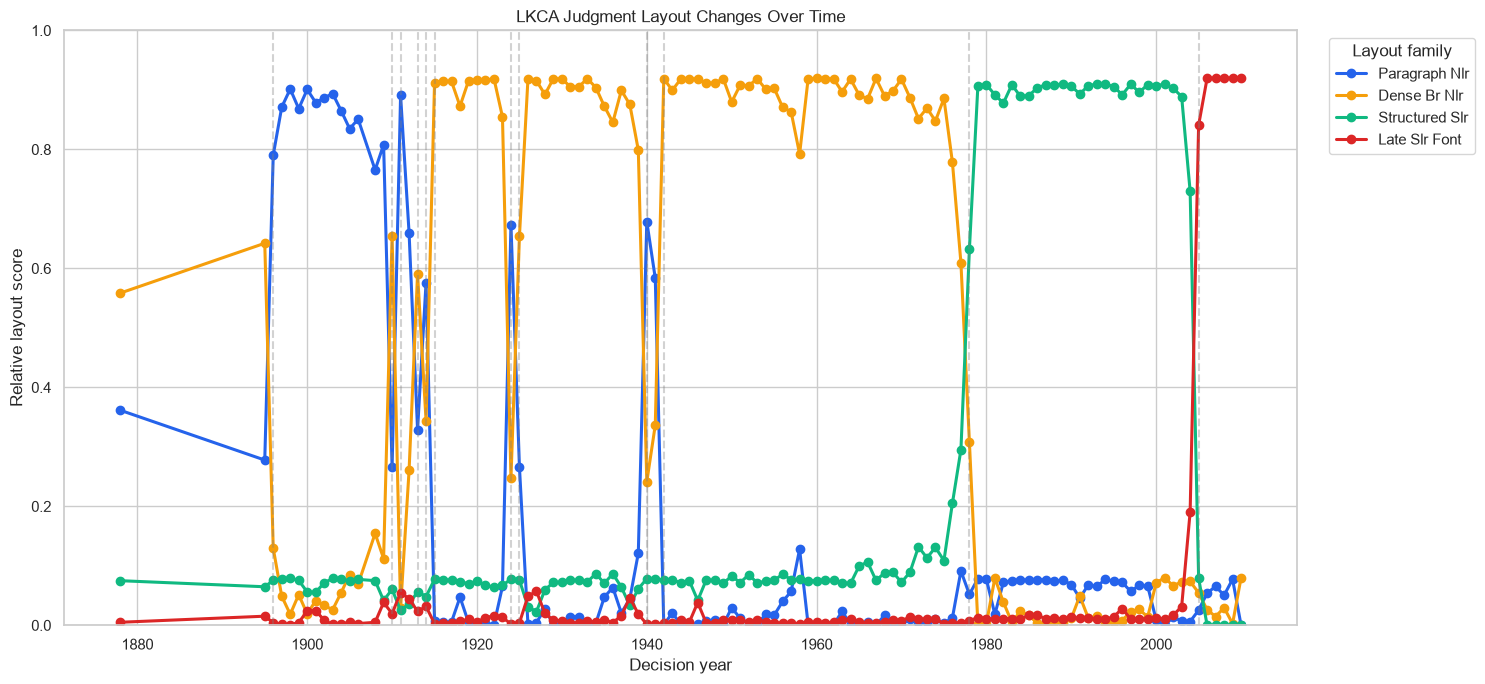

In [10]:
OUTPUT_DIR.mkdir(exist_ok=True)

df.to_csv(OUTPUT_DIR / "layout-eda-records.csv", index=False)
yearly_scores.to_csv(OUTPUT_DIR / "layout-scores-by-year.csv")
transitions.to_csv(OUTPUT_DIR / "layout-transitions.csv")
uncertain.to_csv(OUTPUT_DIR / "uncertain-layouts.csv", index=False)
bucket_df.to_csv(OUTPUT_DIR / "layout-bucket-counts.csv", index=False)

fig, ax = plt.subplots(figsize=(15, 7))

for layout in LAYOUTS:
    ax.plot(
        yearly_scores.index,
        yearly_scores[layout],
        marker="o",
        linewidth=2.2,
        label=layout.replace("_", " ").title(),
        color=COLORS[layout],
    )

for year in change_years[1:]:
    ax.axvline(year, color="grey", linestyle="--", alpha=0.35)

ax.set_title("LKCA Judgment Layout Changes Over Time")
ax.set_xlabel("Decision year")
ax.set_ylabel("Relative layout score")
ax.set_ylim(0, 1)
ax.legend(title="Layout family", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "layout-changes-over-time.png", dpi=300, bbox_inches="tight")

print(f"Saved EDA outputs to: {OUTPUT_DIR.resolve()}")
plt.show()
